In [1]:
pip install coronagraph

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import coronagraph as cg

In [3]:
DATA_FILE = "PSO318-22.csv"
MODEL_DIR = os.path.join("SM08_grid_model-20221222T220547Z-001", "SM08_grid_model")
REFERENCE_MODEL = "sp_t1500g3000f2"

teff_list = ["800", "900", "1000", "1100", "1200", "1300", "1400", "1500"]
logg_list = ["100", "300", "1000", "3000"]
fsed_list = ["1", "2", "3", "4"]

lammin = 0.6
lammax = 20
R = 100

plt.rcParams["figure.figsize"] = [10, 5]

In [4]:
df = pd.read_csv(DATA_FILE)
good = df[["wavelength", "flux", "flux_err"]].notna().all(axis=1).to_numpy()

wavelength = df.wavelength.to_numpy()[good]
flux = df.flux.to_numpy()[good]
flux_err = df.flux_err.to_numpy()[good]

In [5]:
def load_model(name):
    path = os.path.join(MODEL_DIR, name)
    return np.genfromtxt(path, dtype=float, encoding="cp437", comments="#", skip_header=2)


model_wavelength = load_model(REFERENCE_MODEL)[:, 0]

grid = np.full(
    (len(teff_list), len(logg_list), len(fsed_list), len(model_wavelength)), np.nan
)

for i, teff in enumerate(teff_list):
    for j, logg in enumerate(logg_list):
        for k, fsed in enumerate(fsed_list):
            name = f"sp_t{teff}g{logg}f{fsed}"
            if os.path.isfile(os.path.join(MODEL_DIR, name)):
                grid[i, j, k] = load_model(name)[:, 1]

In [6]:
bin_wavelength, bin_width = cg.noise_routines.construct_lam(lammin, lammax, R)


def reduce(model_wl, model_flux, target_wl):
    binned = cg.downbin_spec(model_flux, model_wl, bin_wavelength, dlam=bin_width)
    return interp1d(bin_wavelength, binned, kind="linear")(target_wl)


reduced_grid = np.full(grid.shape[:3] + (len(wavelength),), np.nan)

for idx in np.ndindex(grid.shape[:3]):
    if not np.isnan(grid[idx]).all():
        reduced_grid[idx] = reduce(model_wavelength, grid[idx], wavelength)

In [7]:
def C_val(model):
    return np.sum(flux * model / flux_err**2) / np.sum(model**2 / flux_err**2)


def G_val(scale, model):
    return np.sum(((flux - scale * model) / flux_err) ** 2)


CVAL1 = np.full(grid.shape[:3], np.nan)
GVAL1 = np.full(grid.shape[:3], np.nan)

for idx in np.ndindex(GVAL1.shape):
    model = reduced_grid[idx]
    if np.isnan(model).all():
        continue
    CVAL1[idx] = C_val(model)
    GVAL1[idx] = G_val(CVAL1[idx], model)

In [8]:
best = np.unravel_index(np.nanargmin(GVAL1), GVAL1.shape)
best_model = CVAL1[best] * reduced_grid[best]

print("Teff:", teff_list[best[0]])
print("log g:", logg_list[best[1]])
print("fsed:", fsed_list[best[2]])
print("chi2:", GVAL1[best])
print("scale:", CVAL1[best])

Teff: 1500
log g: 3000
fsed: 2
chi2: 2480.9747286822617
scale: 3.9991612634642314e-11


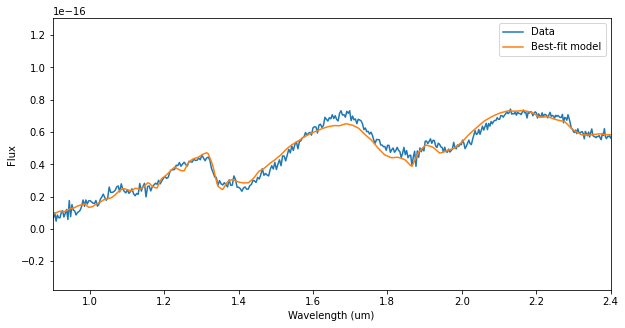

In [9]:
plt.plot(wavelength, flux, label="Data")
plt.plot(wavelength, best_model, label="Best-fit model")
plt.xlim(0.9, 2.4)
plt.xlabel("Wavelength (um)")
plt.ylabel("Flux")
plt.legend()
plt.show()

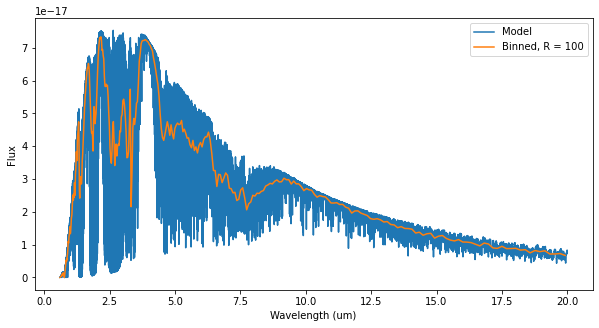

In [10]:
full_res = CVAL1[best] * grid[best]
binned = cg.downbin_spec(full_res, model_wavelength, bin_wavelength, dlam=bin_width)
in_range = (model_wavelength > lammin) & (model_wavelength < lammax)

plt.plot(model_wavelength[in_range], full_res[in_range], label="Model")
plt.plot(bin_wavelength, binned, label=f"Binned, R = {R}")
plt.xlabel("Wavelength (um)")
plt.ylabel("Flux")
plt.legend()
plt.show()